# Case study 2 — Multi-scale decomposition and rolling normalisation

Reproduces the decomposition demonstration and the rolling-window analysis of
the normet paper (Sects. *Multi-scale decomposition* and *Rolling-window
normalisation across meteorological timescales*) on the bundled MY1 NO2
dataset (Jan–Aug 2020).

In [1]:
import os

# Cap library threads BEFORE importing normet/lightgbm — on shared machines
# (HPC login nodes, CI runners) unbounded OpenMP threads can oversubscribe
# the node and appear to hang.
os.environ.setdefault("OMP_NUM_THREADS", "4")

import matplotlib.pyplot as plt
import normet as nm

my1 = nm.datasets.load_my1()

MET_VARS = ["ws", "wd", "temp", "RH", "atmos_pres", "blh", "tcc", "tp", "ssrd"]
TIME_VARS = ["date_unix", "day_julian", "weekday", "hour"]
PREDICTORS = MET_VARS + TIME_VARS
SEED = 7654321

prep, model = nm.build_model(
    my1, target="NO2", backend="lightgbm", covariates=PREDICTORS,
    split_method="random", train_fraction=0.75, seed=SEED, verbose=False, n_cores=4,
    model_config={"n_trials": 4, "cv_folds": 2, "nrounds": 150, "early_stopping_rounds": 10},
)
nm.modStats(prep, model)

,n,FAC2,MB,MGE,RMSE,NMB,NMGE,COE,IOA,r,p_level,R2,set
0,4345,0.993786,-0.038671,4.906411,6.582947,-0.000895,0.113572,0.759559,0.879780,0.965548,***,0.932283,training
1,1448,0.978591,0.250332,6.885762,9.231537,0.005886,0.161913,0.664659,0.832329,0.930924,***,0.866620,testing
2,5793,0.989988,0.033567,5.401163,7.335182,0.000780,0.125513,0.735786,0.867893,0.956847,***,0.915556,all


## 1. Emission-driven vs meteorology-driven components

`nm.decompose(method="emission")` resamples the *time* features to isolate
the systematic emission signal (trend, season, weekday, hour) from the
meteorology-driven variability.

In [2]:
decomp = nm.decompose(
    method="emission", df=prep, model=model,
    covariates=PREDICTORS, n_samples=50, seed=SEED, n_cores=4, verbose=False,
)
decomp.head()

,observed,date_unix,day_julian,weekday,hour,emi_total,emi_noise,emi_base
date,,,,,,,,
2020-01-01 00:00:00,45.77784,5.707530,3.191896,4.194537,-13.886477,46.608368,4.407162,42.993721
2020-01-01 01:00:00,52.64325,5.324263,3.778850,1.519153,-12.189382,45.796233,4.369628,42.993721
2020-01-01 02:00:00,44.76870,10.839705,5.508026,2.369239,-16.149555,36.118605,-9.442531,42.993721
2020-01-01 03:00:00,40.20699,8.216058,4.112145,2.570097,-18.882269,40.730868,1.721115,42.993721
2020-01-01 04:00:00,47.26010,8.571531,4.260480,2.763968,-17.529162,39.182859,-1.877679,42.993721


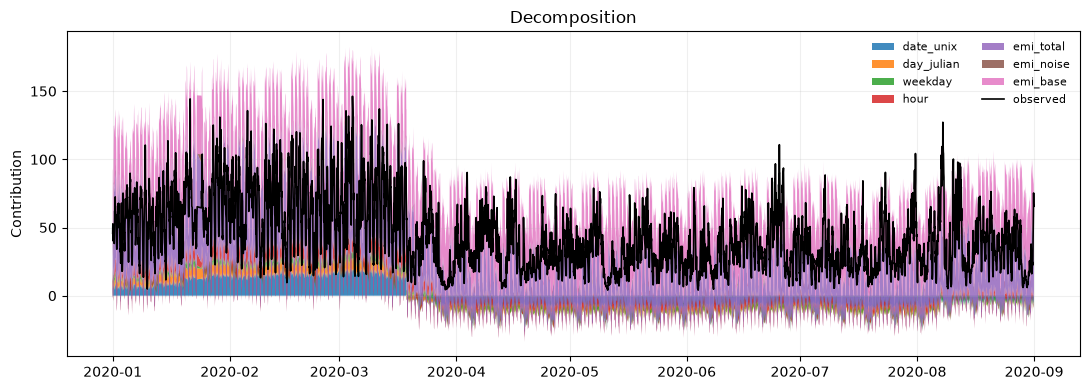

In [3]:
nm.decomposition_stack(decomp)
plt.tight_layout()

## 2. Rolling-window normalisation

Normalising within a moving window separates the timescales the model can
marginalise over: short windows remove only synoptic-scale weather, long
windows also remove seasonality. The paper contrasts 14-day, 90-day, and
global windows; here we run a 14-day window on the 8-month case data.

In [4]:
roll = nm.rolling(
    prep, model=model, covariates=PREDICTORS, variables_resample=MET_VARS,
    window_days=14, rolling_every=14, n_samples=20, seed=SEED, n_cores=4, verbose=False,
)
roll.head()

,observed,rolling_0,rolling_1,rolling_2,rolling_3,rolling_4,rolling_5,rolling_6,rolling_7,rolling_8,rolling_9,rolling_10,rolling_11,rolling_12,rolling_13,rolling_14,rolling_15,rolling_16
date,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,45.77784,37.304369,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 01:00:00,52.64325,36.791112,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 02:00:00,44.76870,30.148718,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 03:00:00,40.20699,31.528600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 04:00:00,47.26010,38.015239,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


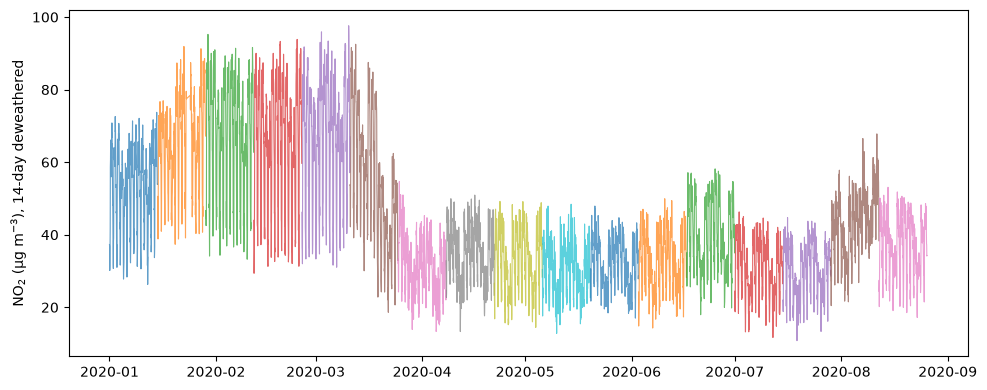

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
value_cols = [c for c in roll.columns if c.startswith("rolling_")]
dates = roll.index if roll.index.name == "date" else roll["date"]
for c in value_cols:
    ax.plot(dates, roll[c], lw=0.8, alpha=0.7)
ax.set_ylabel("NO$_2$ (µg m$^{-3}$), 14-day deweathered")
plt.tight_layout()